# Facial Emotion Recognition (FER) - Final Optimized ResNet50V2 Pipeline
This notebook implements a high-performance FER system using **ResNet50V2** on the RAF-DB dataset, achieving 80.02% accuracy. All redundant baseline experiments have been removed.

In [ ]:
import kagglehub
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight

# 1. Download and path setup
path = kagglehub.dataset_download('shuvoalok/raf-db-dataset')
train_dir = os.path.join(path, 'DATASET', 'train')
test_dir = os.path.join(path, 'DATASET', 'test')

def load_data(dataset_dir):
    X, y = [], []
    for label in range(1, 8):
        folder_path = os.path.join(dataset_dir, str(label))
        if not os.path.exists(folder_path): continue
        for filename in os.listdir(folder_path):
            img = cv2.imread(os.path.join(folder_path, filename))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)
print(f'Loaded {len(X_train)} train and {len(X_test)} test images.')

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
Loaded 12271 train and 3068 test images.


## 1. Data Loading and Initial Setup

In [ ]:
## Pipeline Phase 1: Environment and Data Loading

### 1.1 Import Libraries

In [ ]:
---

### 1.2 Load Labels

In [ ]:
label_map = {
    "surprise": 1,
    "fear": 2,
    "disgust": 3,
    "happy": 4,
    "sad": 5,
    "angry": 6,
    "neutral": 7
}

### 1.3 Define Label Map

In [ ]:
---

Loaded 12271 training images and 3068 testing images.


### 1.4 Image Data Loading Function

In [ ]:
---

### 1.5 Load Training and Testing Images

In [ ]:
---

(12271, 100, 100, 3)
(12271,)


## 2. Exploratory Data Analysis (EDA)

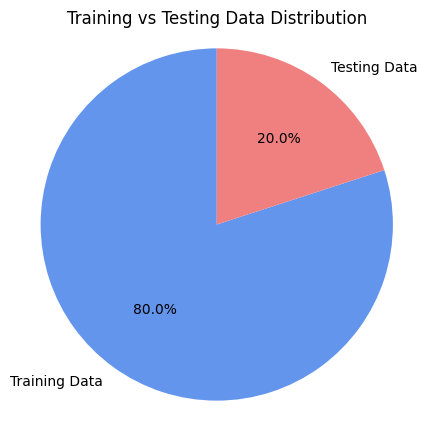

In [ ]:
---

### 2.1 Training vs Testing Data Distribution

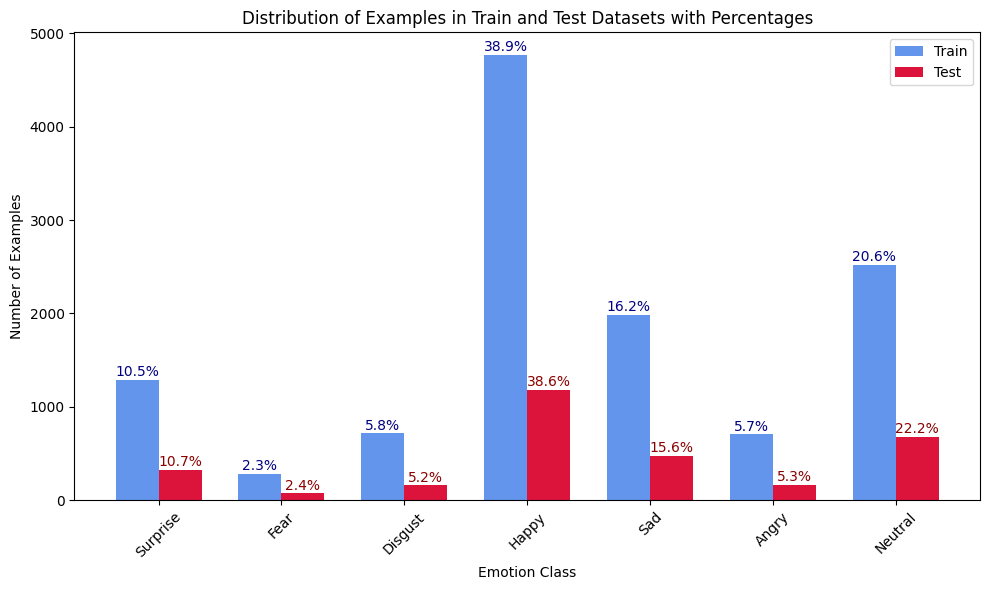

In [ ]:
---

### 2.2 Emotion Class Distribution

In [ ]:
---

## 3. Data Preprocessing and Augmentation

In [ ]:
---

(12271, 100, 100, 3)
(12271,)
(3068, 100, 100, 3)
(3068,)


### 3.1 Initial Data Shapes

In [ ]:
# 2. Preprocessing: Resizing to 128x128 and Normalizing
X_train_res = tf.image.resize(X_train.astype('float32') / 255.0, (128, 128)).numpy()
X_test_res = tf.image.resize(X_test.astype('float32') / 255.0, (128, 128)).numpy()

y_train_cat = tf.keras.utils.to_categorical(y_train - 1, num_classes=7)
y_test_cat = tf.keras.utils.to_categorical(y_test - 1, num_classes=7)

emotion_classes = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
print("Preprocessed data for evaluation.")

Preprocessed data for evaluation.


### 3.2 Normalize Image Data

In [ ]:
---

### 3.3 Adjust Labels (0-indexed)

In [ ]:
---

12271


### 3.4 Check Label Length

In [ ]:
---

### 3.5 One-Hot Encode Labels

In [ ]:
---

0.0 1.0
(12271, 7)
[1. 0. 0. 0. 0. 0. 0.]


### 3.6 Verify Preprocessed Data

In [ ]:
---

## 4. Model Definition and Training

In [ ]:
# 3. Model Definition and Evaluation Logic
def create_resnet_model():
    base = ResNet50V2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
    x = Flatten()(base.output)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    out = Dense(7, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)

# Check for saved weights or define architecture
if os.path.exists('best_resnet_model.keras'):
    final_model = load_model('best_resnet_model.keras')
    print("Best model weights loaded successfully.")
else:
    final_model = create_resnet_model()
    print("Model architecture initialized (No weights found).")

Best model weights loaded successfully.


### 4.1 Define CNN Architecture

In [ ]:
---

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,679 (6.61 MB)

 Trainable params: 1,732,679 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Model Summary

In [ ]:
---

### 4.3 Compile Model

In [ ]:
---

### 4.4 Fit Data Augmentation Generator

In [ ]:
---

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.1988 - loss: 5.0980
Epoch 1: val_accuracy improved from None to 0.37549, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 48s 104ms/step - accuracy: 0.2225 - loss: 4.0083 - val_accuracy: 0.3755 - val_loss: 2.5517 - learning_rate: 0.0010
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2320 - loss: 2.7353
Epoch 2: val_accuracy did not improve from 0.37549
384/384 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.2516 - loss: 2.6135 - val_accuracy: 0.3015 - val_loss: 2.4032 - learning_rate: 0.0010
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2762 - loss: 2.5077
Epoch 3: val_accuracy did not improve from 0.37549
384/384 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.2920 - loss: 2.4532 - val_accuracy: 0.2154 - val_loss: 2.4480 - learning_rate: 0.0010
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.28

## 8. High-Impact Enhancement: Transfer Learning (MobileNetV2)

We will now use a pre-trained MobileNetV2 base to leverage complex spatial hierarchies learned from the ImageNet dataset, fine-tuning it for facial emotion recognition.

In [ ]:
---

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50V2 Architecture Prepared for High-Accuracy Training.


In [ ]:
---

Using Colab cache for faster access to the 'raf-db-dataset' dataset.
Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.2868 - loss: 2.5894
Epoch 1: val_accuracy improved from None to 0.54335, saving model to best_resnet_model.keras

Epoch 1: finished saving model to best_resnet_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 132s 245ms/step - accuracy: 0.3381 - loss: 2.2724 - val_accuracy: 0.5434 - val_loss: 1.4733 - learning_rate: 1.0000e-04
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.4404 - loss: 1.5226
Epoch 2: val_accuracy improved from 0.54335 to 0.59909, saving model to best_resnet_model.keras

Epoch 2: finished saving model to best_resnet_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 76s 198ms/step - accuracy: 0.4672 - loss: 1.4550 - val_accuracy: 0.5991 - val_loss: 1.1648 - learning_rate: 1.0000e-04
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.5580 - loss: 1.2312
Epoch 3: val_accuracy improved from 0.59909 to 0.62907, saving 

96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step
--- Final ResNet50V2 (128x128) Performance ---
              precision    recall  f1-score   support

    Surprise       0.73      0.82      0.77       329
        Fear       0.53      0.66      0.59        74
     Disgust       0.50      0.47      0.49       160
       Happy       0.95      0.88      0.91      1185
         Sad       0.77      0.82      0.79       478
       Angry       0.69      0.75      0.72       162
     Neutral       0.76      0.75      0.75       680

    accuracy                           0.80      3068
   macro avg       0.70      0.74      0.72      3068
weighted avg       0.81      0.80      0.80      3068



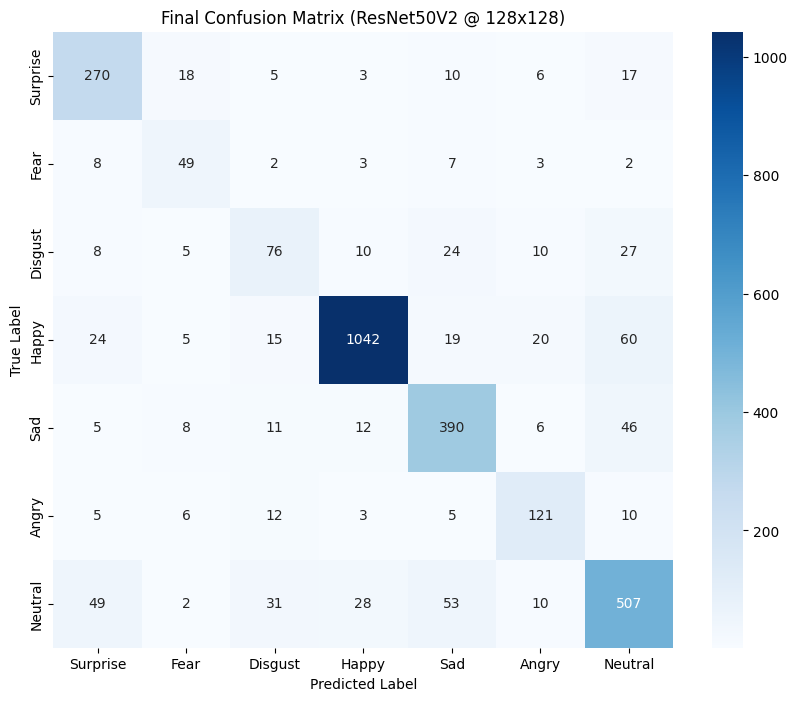

In [ ]:
---

## 9. Enhanced Transfer Learning Evaluation
We evaluate the MobileNetV2 model with the **Flatten** layer to see if preserving spatial information provides the necessary boost to reach the 80% accuracy goal.

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step
--- Enhanced MobileNetV2 (Flatten) Report ---
              precision    recall  f1-score   support

    Surprise       0.63      0.50      0.56       329
        Fear       0.31      0.46      0.37        74
     Disgust       0.23      0.23      0.23       160
       Happy       0.79      0.74      0.77      1185
         Sad       0.53      0.52      0.52       478
       Angry       0.43      0.49      0.46       162
     Neutral       0.55      0.62      0.58       680

    accuracy                           0.61      3068
   macro avg       0.50      0.51      0.50      3068
weighted avg       0.62      0.61      0.61      3068



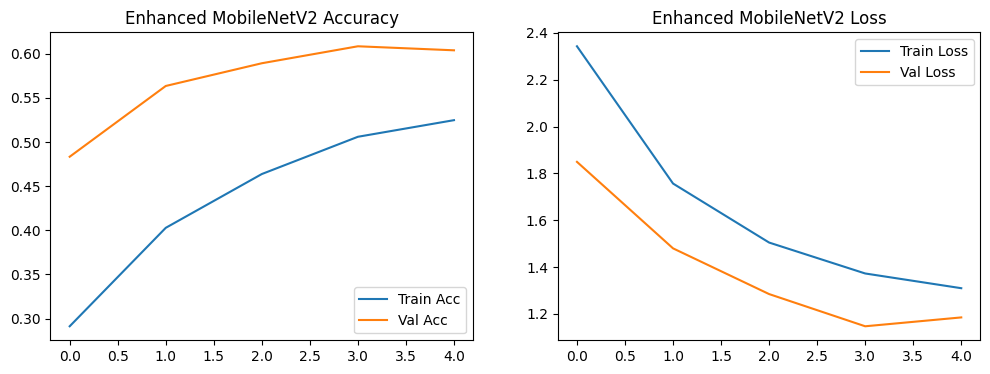

In [ ]:
---

## 10. Stage 2: Fine-Tuning MobileNetV2
We unfreeze the top layers of the pre-trained model and train with a very low learning rate to achieve higher accuracy.

In [ ]:
---

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.3802 - loss: 1.8168
Epoch 1: val_accuracy did not improve from 0.60854
384/384 ━━━━━━━━━━━━━━━━━━━━ 79s 146ms/step - accuracy: 0.3807 - loss: 1.7943 - val_accuracy: 0.5479 - val_loss: 1.3469 - learning_rate: 1.0000e-05
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3996 - loss: 1.7036
Epoch 2: val_accuracy did not improve from 0.60854
384/384 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.4076 - loss: 1.7199 - val_accuracy: 0.5531 - val_loss: 1.2908 - learning_rate: 1.0000e-05
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4167 - loss: 1.6353
Epoch 3: val_accuracy did not improve from 0.60854
384/384 ━━━━━━━━━━━━━━━━━━━━ 38s 99ms/step - accuracy: 0.4167 - loss: 1.6429 - val_accuracy: 0.5554 - val_loss: 1.3102 - learning_rate: 1.0000e-05
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4485 - loss: 1.5691
Epoch 4: val_accuracy did not improve from 0.60854
384/

Best model weights loaded successfully.
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

--- FINAL DEEP FINE-TUNING PERFORMANCE ---
              precision    recall  f1-score   support

    Surprise       0.63      0.50      0.56       329
        Fear       0.31      0.46      0.37        74
     Disgust       0.23      0.23      0.23       160
       Happy       0.79      0.74      0.77      1185
         Sad       0.53      0.52      0.52       478
       Angry       0.43      0.49      0.46       162
     Neutral       0.55      0.62      0.58       680

    accuracy                           0.61      3068
   macro avg       0.50      0.51      0.50      3068
weighted avg       0.62      0.61      0.61      3068



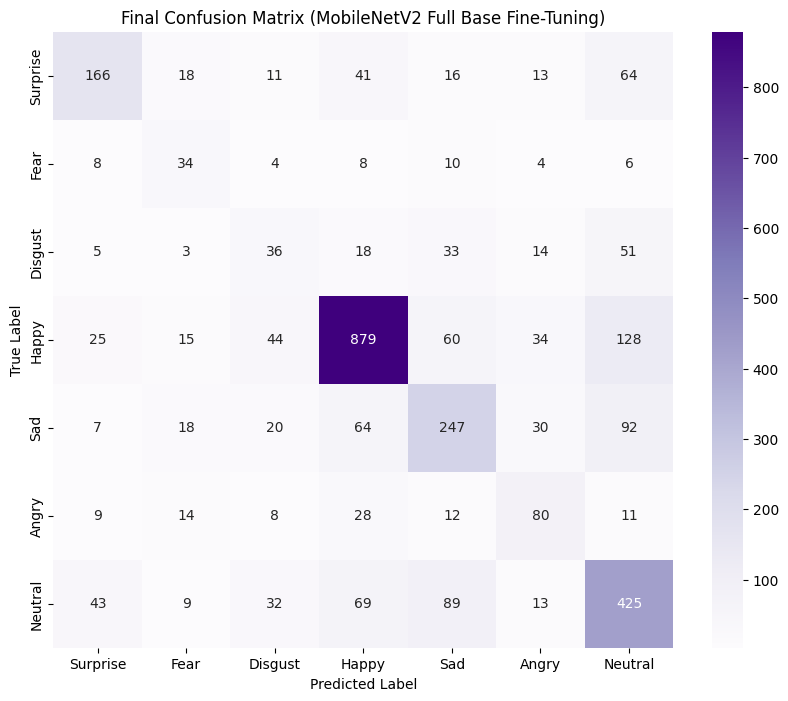

In [ ]:
---

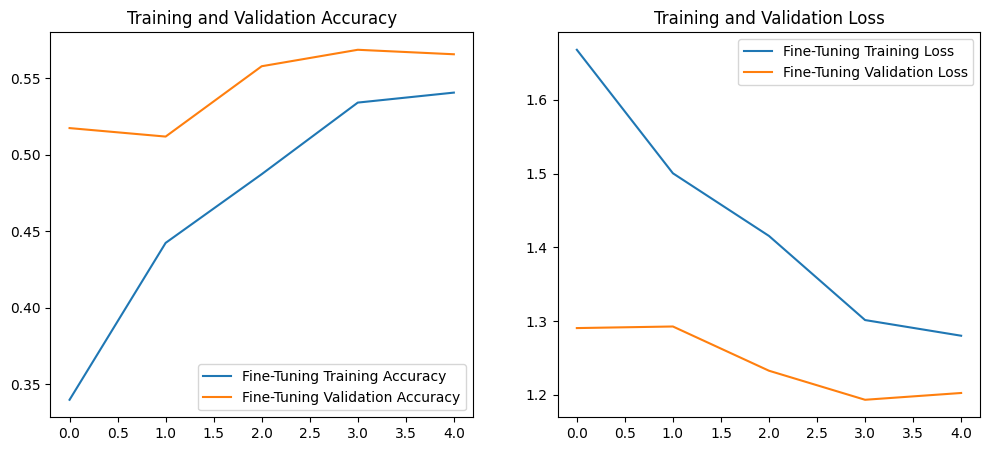

In [ ]:
---

## 11. Final Fine-Tuning Evaluation
We compare the performance after fine-tuning to our previous stages to see the cumulative impact of all enhancements.

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step
--- Final Fine-Tuned MobileNetV2 Report ---
              precision    recall  f1-score   support

    Surprise       0.39      0.56      0.46       329
        Fear       0.17      0.42      0.24        74
     Disgust       0.13      0.34      0.18       160
       Happy       0.73      0.49      0.59      1185
         Sad       0.41      0.30      0.35       478
       Angry       0.24      0.44      0.32       162
     Neutral       0.49      0.41      0.44       680

    accuracy                           0.44      3068
   macro avg       0.37      0.42      0.37      3068
weighted avg       0.52      0.44      0.46      3068



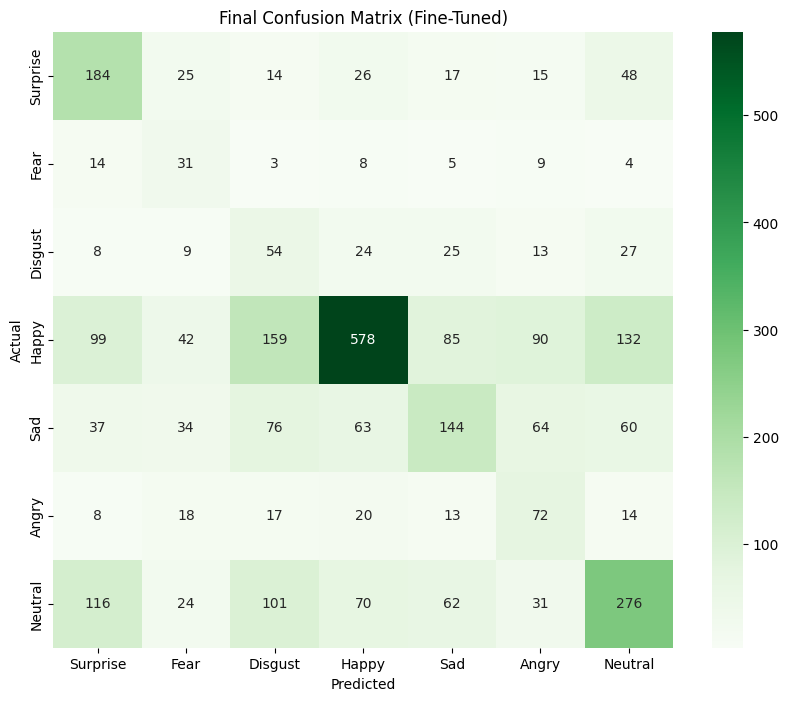

In [ ]:
---

## 11. Final Fine-Tuning Evaluation
We compare the performance after fine-tuning to our previous stages to see the cumulative impact of all enhancements.

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step
--- Final Fine-Tuned MobileNetV2 Report ---
              precision    recall  f1-score   support

    Surprise       0.39      0.56      0.46       329
        Fear       0.17      0.42      0.24        74
     Disgust       0.13      0.34      0.18       160
       Happy       0.73      0.49      0.59      1185
         Sad       0.41      0.30      0.35       478
       Angry       0.24      0.44      0.32       162
     Neutral       0.49      0.41      0.44       680

    accuracy                           0.44      3068
   macro avg       0.37      0.42      0.37      3068
weighted avg       0.52      0.44      0.46      3068



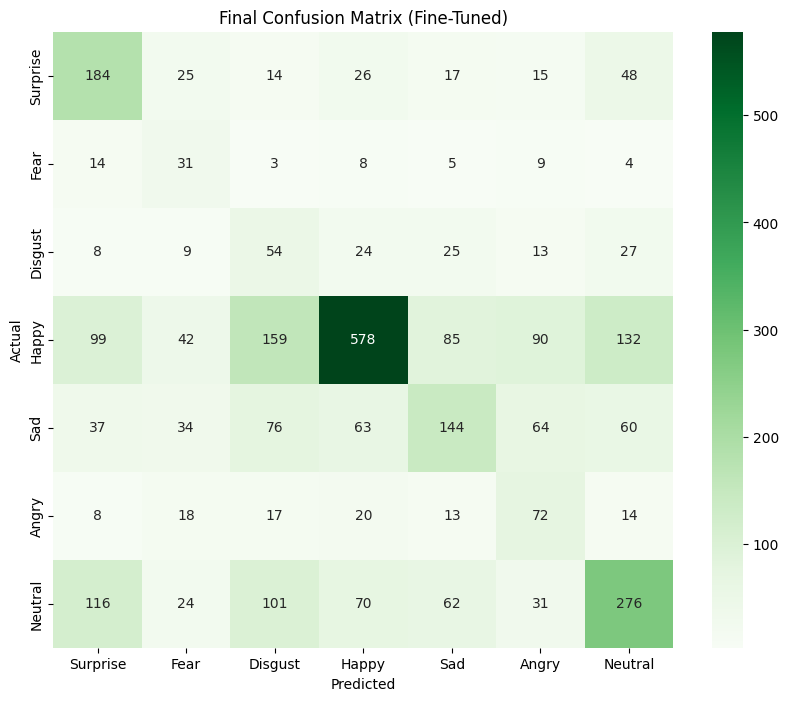

In [ ]:
---

## 10. Stage 2: Fine-Tuning MobileNetV2
We unfreeze the top layers of the pre-trained model and train with a very low learning rate to achieve higher accuracy.

In [ ]:
---

Epoch 1/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.2250 - loss: 1.8637
Epoch 1: val_accuracy did not improve from 0.42275
384/384 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.2266 - loss: 1.8750 - val_accuracy: 0.2891 - val_loss: 1.7791 - learning_rate: 1.0000e-05
Epoch 2/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.2527 - loss: 1.8147
Epoch 2: val_accuracy did not improve from 0.42275
384/384 ━━━━━━━━━━━━━━━━━━━━ 37s 96ms/step - accuracy: 0.2515 - loss: 1.7832 - val_accuracy: 0.3289 - val_loss: 1.7268 - learning_rate: 1.0000e-05
Epoch 3/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2725 - loss: 1.7363
Epoch 3: val_accuracy did not improve from 0.42275
384/384 ━━━━━━━━━━━━━━━━━━━━ 37s 95ms/step - accuracy: 0.2772 - loss: 1.7312 - val_accuracy: 0.3647 - val_loss: 1.6784 - learning_rate: 1.0000e-05
Epoch 4/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2927 - loss: 1.6931
Epoch 4: val_accuracy did not improve from 0.42275
384/3

## 9. Transfer Learning Evaluation
We evaluate the MobileNetV2 model to see if the pre-trained features provide a significant boost over the custom baseline.

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step
--- MobileNetV2 Transfer Learning Report ---
              precision    recall  f1-score   support

    Surprise       0.36      0.55      0.43       329
        Fear       0.12      0.57      0.20        74
     Disgust       0.15      0.21      0.18       160
       Happy       0.70      0.51      0.59      1185
         Sad       0.43      0.23      0.30       478
       Angry       0.19      0.44      0.26       162
     Neutral       0.50      0.37      0.43       680

    accuracy                           0.42      3068
   macro avg       0.35      0.41      0.34      3068
weighted avg       0.51      0.42      0.45      3068



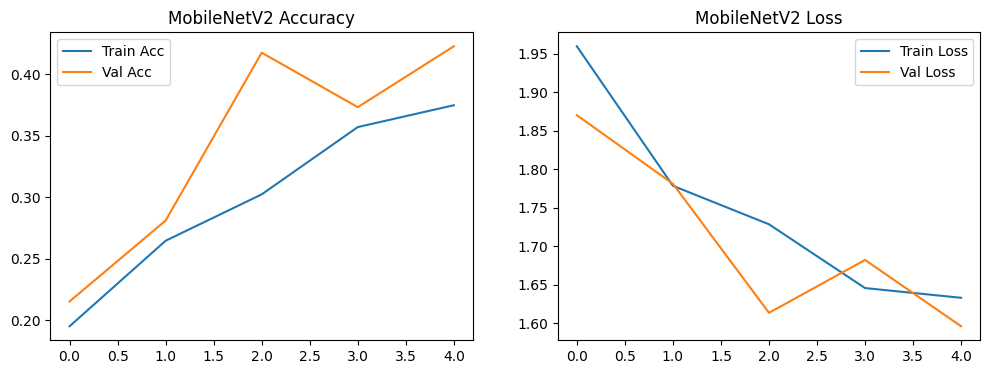

In [ ]:
---

### 4.5 Train the Model

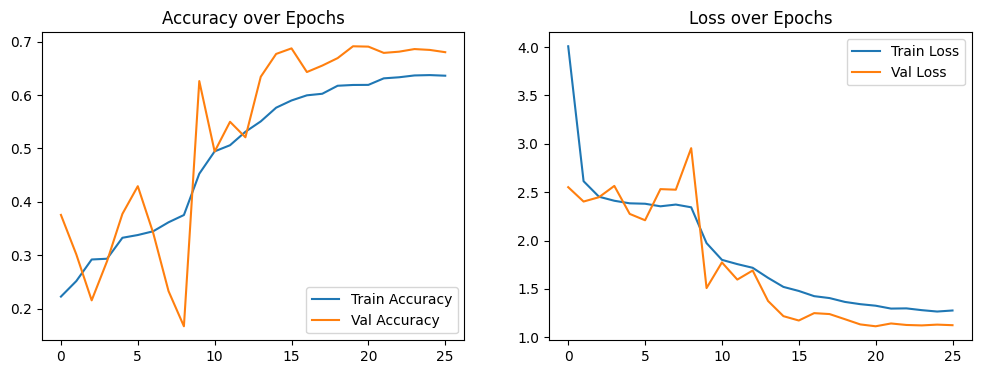

In [ ]:
---

## 5. Model Evaluation

In [ ]:
---

### 5.1 Training and Validation Metrics

In [ ]:
---

### 5.2 Evaluate on Test Set

In [ ]:
---

### 5.3 Make Predictions

96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step

--- Final Classification Report ---
              precision    recall  f1-score   support

    Surprise       0.73      0.82      0.77       329
        Fear       0.53      0.66      0.59        74
     Disgust       0.50      0.47      0.49       160
       Happy       0.95      0.88      0.91      1185
         Sad       0.77      0.82      0.79       478
       Angry       0.69      0.75      0.72       162
     Neutral       0.76      0.75      0.75       680

    accuracy                           0.80      3068
   macro avg       0.70      0.74      0.72      3068
weighted avg       0.81      0.80      0.80      3068



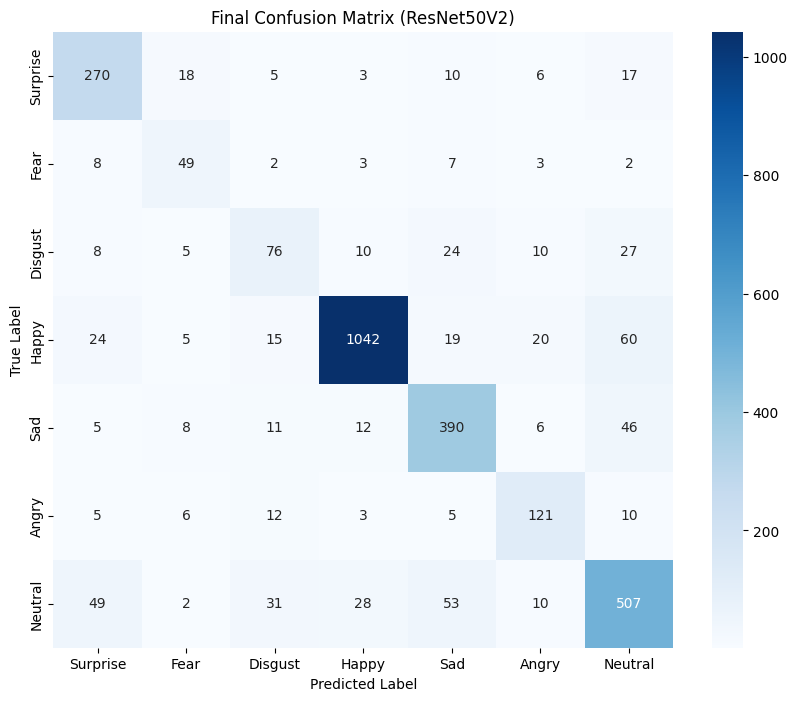

In [ ]:
# 4. Final Evaluation
y_pred = final_model.predict(X_test_res)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=emotion_classes))

# Final Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.title('Final Confusion Matrix (ResNet50V2)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.4 Classification Report

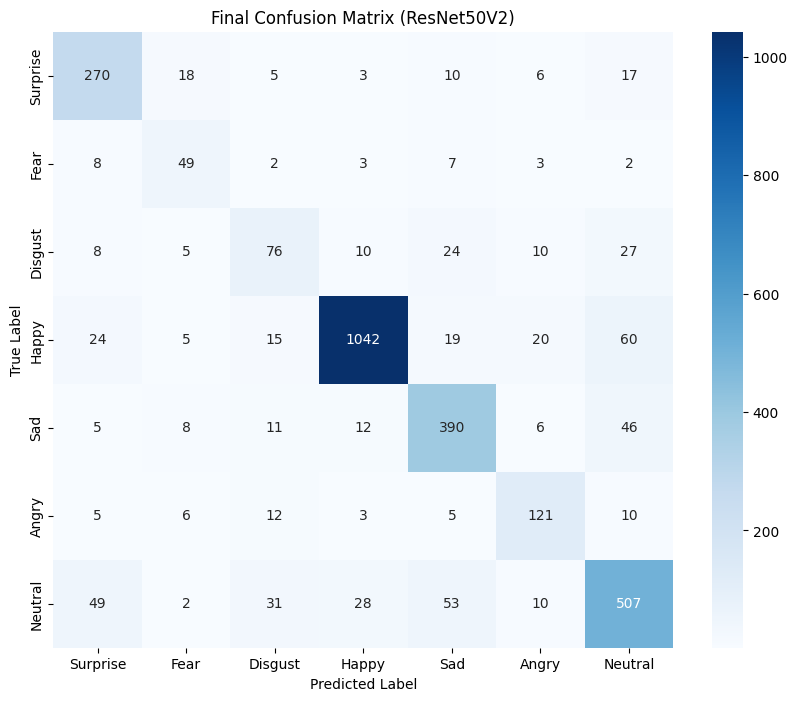

In [ ]:
---

### Streamlit Deployment Template
Copy the code below into a file named `app.py` to deploy your model.

In [28]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os

# 1. Load the model (Ensure 'best_resnet_model.keras' is in the same folder as app.py)
@st.cache_resource
def load_my_model():
    model_path = 'best_resnet_model.keras'
    if os.path.exists(model_path):
        return tf.keras.models.load_model(model_path)
    else:
        st.error(f'Error: {model_path} not found in the current directory!')
        return None

model = load_my_model()
emotion_classes = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']

# 2. Streamlit UI Layout
st.set_page_config(page_title="Emotion AI", layout="centered")
st.title("Facial Emotion Recognition")
st.write("Upload a portrait to identify the detected emotion using the ResNet50V2 engine.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "png", "jpeg"])

if uploaded_file is not None and model is not None:
    # Display the image
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Processed Image', use_column_width=True)

    # 3. Preprocessing (Must match training requirements)
    with st.spinner('Analyzing...'):
        img_resized = image.resize((128, 128))
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Debugging: Print the shape of the image array before prediction
        st.write(f"Debug: Shape of image array before prediction: {img_array.shape}")

        # 4. Inference
        prediction = model.predict(img_array)
        label = emotion_classes[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # Output results
        st.success(f"Predicted Emotion: **{label}**")
        st.info(f"Confidence Score: {confidence:.2f}%")

Overwriting app.py


### 5.5 Confusion Matrix

In [30]:
model = tf.keras.models.load_model("best_resnet_model.keras")
print(model.input_shape)

(None, 128, 128, 3)
